In [24]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [25]:
df = pd.read_csv("housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [26]:
df.shape

(545, 13)

In [27]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [29]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [30]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [31]:
X = df[["area", "bedrooms", "bathrooms", "stories", "parking"]]
y = df["price"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [33]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (436, 5)
X_test: (109, 5)
y_train: (436,)
y_test: (109,)


In [34]:
model = LinearRegression()

In [35]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 308.87, 151246.75,1185731.71, 495100.76, 337660.83]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['area','bedrooms','bathrooms','stories','parking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.2e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [36]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 51999.67680883687
Coefficients: [3.08866956e+02 1.51246751e+05 1.18573171e+06 4.95100763e+05
 3.37660830e+05]


In [37]:
y_pred = model.predict(X_test)

In [38]:
print(y_pred[:10])

[6178627.50326817 6370140.85865473 3283148.1570249  4226007.94816032
 3409685.55116741 4262158.3499693  5493440.53152357 5559897.74293016
 3373715.42245305 3020513.18649699]


In [39]:
comparison_df = pd.DataFrame({"Actual Price" : y_test, "Predicted price" : y_pred})
comparison_df.head(10)

,Actual Price,Predicted price
316,4060000,6.178628e+06
77,6650000,6.370141e+06
360,3710000,3.283148e+06
90,6440000,4.226008e+06
493,2800000,3.409686e+06
209,4900000,4.262158e+06
176,5250000,5.493441e+06
249,4543000,5.559898e+06
516,2450000,3.373715e+06
426,3353000,3.020513e+06


In [40]:
mae = mean_absolute_error(y_test, y_pred)
print ("MAE:", mae)

MAE: 1127483.3523235188


In [41]:
mse = mean_squared_error(y_test, y_pred)
print ("MSE:", mse)

MSE: 2292721545725.3623


In [42]:
rmse = np.sqrt(mse)
print ("RMSE:", rmse)

RMSE: 1514173.5520492233


In [43]:
r2_score_value = r2_score(y_test, y_pred)
print("R Squared Score:", r2_score_value)

R Squared Score: 0.5464062355495871


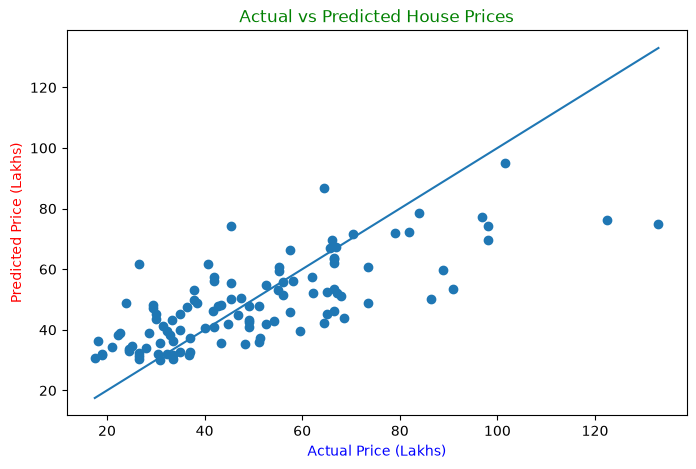

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test / 100000, y_pred / 100000)

plt.plot(
    [y_test.min() / 100000, y_test.max() / 100000],
    [y_test.min() / 100000, y_test.max() / 100000]
)

plt.xlabel("Actual Price (Lakhs)", color='blue')
plt.ylabel("Predicted Price (Lakhs)", color='red')
plt.title("Actual vs Predicted House Prices", color='green')

plt.show()

In [45]:
coefficient = pd.DataFrame({"feature": X.columns, "coefficient": model.coef_})
coefficient

,feature,coefficient
0,area,3.088670e+02
1,bedrooms,1.512468e+05
2,bathrooms,1.185732e+06
3,stories,4.951008e+05
4,parking,3.376608e+05


In [46]:
print("Intercept:", model.intercept_)

Intercept: 51999.67680883687


## Conclusion

In this project, I built a Linear Regression model to predict house prices using features such as area, bedrooms, bathrooms, stories, and parking.

The model was trained using the training dataset and evaluated on unseen test data using MAE, MSE, RMSE, and R².

The Actual vs Predicted graph helped visualize how closely the model's predictions matched the real house prices.

The model coefficients also helped understand how each feature influenced the predicted house price.

Overall, this project helped me understand the complete basic Machine Learning workflow from data loading and preprocessing to model training, prediction, evaluation, and interpretation.
